# Virtual dataset reader and plotter
### Example for NASA CMR Shortname: SWOT_L2_LR_SSH_Basic_D

#### *Author: Ed Armstrong, PO.DAAC*

*Reference herein to any specific commercial product, process, or service by trade name, trademark, manufacturer, or otherwise, does not constitute or imply its endorsement by the United States Government or the Jet Propulsion Laboratory, California Institute of Technology.*

### Necessary enviroment includes
##### earthaccess                   0.16.0
##### fsspec                        2025.9.0
##### kerchunk                      0.2.1
##### numpy                         2.3.3
##### xarray                        2025.1.2
#####  zarr                          2.18.6

In [7]:
# install these versions as needed
#!pip install earthaccess==0.16.0 xarray==2025.1.2 zarr==2.18.6  fsspec>=2025.2 numpy virtualizarr==1.3.2 "numcodecs<0.16.0" kerchunk==0.2.1

# updated
#pip install earthaccess==0.16.0 xarray==2025.1.2 zarr==2.18.6 "fsspec>=2025.2" numpy virtualizarr==1.3.2 "numcodecs<0.16.0" kerchunk==0.2.1

zsh:1: 2025.2 not found


In [108]:
!conda list | grep -E '(xarray|numpy|earthaccess|fsspec|zarr|kerchunk|virtualizarr)'

earthaccess               0.16.0                   pypi_0    pypi
fsspec                    2026.3.0           pyhd8ed1ab_0    conda-forge
kerchunk                  0.2.1              pyhd8ed1ab_0    conda-forge
numpy                     2.4.4                    pypi_0    pypi
virtualizarr              1.3.2                    pypi_0    pypi
xarray                    2025.1.2                 pypi_0    pypi
zarr                      2.18.6                   pypi_0    pypi


In [107]:
import sys
print(sys.executable)

/Users/mzahn/miniforge3/envs/vds/bin/python


In [106]:
pip list | grep -E  -e  '(^xarray|numpy|earthaccess|fsspec|zarr|kerchunk)'

earthaccess               0.16.0
fsspec                    2026.3.0
kerchunk                  0.0.0
numpy                     2.4.3
virtualizarr              1.3.2
xarray                    2025.1.2
zarr                      2.18.7
Note: you may need to restart the kernel to use updated packages.


In [76]:
# Filesystem management 
import fsspec
import earthaccess

# Data handling
import xarray as xr
import zarr 

# Numpy
import numpy as np

# Other mapping
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

## 1. Earthdata Cloud authentication


In [3]:
# Get Earthdata creds
earthaccess.login()

## 2. Perform CMR search request and Open VDS reference file

In [60]:
%%time
# Do a simple CMR granule search. We need the results of the granule search to establish AWS credentials if reading the VDS 
# in the cloud.  Otherwise ignore

lat_min, lat_max = -80, 20
lon_min, lon_max = 0, 120

start_time = '2024-05-10T00:28:00'
end_time = '2024-05-10T23:28:00'

short_name = 'SWOT_L2_LR_SSH_Basic_D'
#short_name = 'SCATSAT1_ESDR_L2_WIND_STRESS_V1.1'

granule_result = earthaccess.search_data(
    short_name=short_name,
    temporal=(start_time, end_time),
    bounding_box=(lon_min, lat_min, lon_max, lat_max)
)
print(len(granule_result))

15
CPU times: user 41.9 ms, sys: 8.82 ms, total: 50.7 ms
Wall time: 2.16 s


### 2a. VDS wrapper function for access in cloud or out of cloud

In [61]:
# Open data using the reference file, using a small wrapper function around xarray's open_dataset. 
# This will shorten code blocks in other sections. 
def get_vds_mapper(vds_link, in_cloud_region=False):
    """
    Produces a virtudal dataset mapper that can be passed to xarray. 
    
    * vds_link: str, link to the mapper
    * in_cloud_region: bool, True if in cloud in the same region as the data, 
        False otherwise.
    """

    if in_cloud_region:
        #fs_data = earthaccess.get_s3_filesystem(daac="PODAAC")
        fs_data = earthaccess.get_s3_filesystem(results=granule_result)
        remote_protocol = "s3"
    else:
        fs_data = earthaccess.get_fsspec_https_session()
        # We set this header to identify usage of the VDS. This helps us support continued development. 
        fs_data.client_kwargs['headers']['User-Agent'] = "virtual-dataset-consumer"
        remote_protocol = "https"
    
    storage_opts = {"fo": vds_link, "remote_protocol": remote_protocol, "remote_options": fs_data.storage_options}
    fs_ref = fsspec.filesystem('reference', **storage_opts)
    return fs_ref.get_mapper('')

### 2b. Open VDS as xarray dataset

In [62]:
%%time

# Path to VDSs, both HTTPS and S3 versions
vds_link ='https://archive.podaac.uat.earthdata.nasa.gov/podaac-uat-cumulus-public/virtual_collections/SWOT_L2_LR_SSH_Basic_D/SWOT_L2_LR_SSH_Basic_D_virtual_https.json'
# vds_link ='https://archive.podaac.uat.earthdata.nasa.gov/podaac-uat-cumulus-public/virtual_collections/SWOT_L2_LR_SSH_Basic_D/SWOT_L2_LR_SSH_Basic_D_virtual_s3.json'

# Lets open the JSON VDS as xarray dataset
vds_mapper = get_vds_mapper(vds_link, in_cloud_region=False)

## No modification needed!
data_vds = xr.open_dataset(
    vds_mapper, engine="zarr", chunks={},
    backend_kwargs={"consolidated": False}
)
data_vds
#print(data)


CPU times: user 3.73 s, sys: 1.32 s, total: 5.05 s
Wall time: 23 s


<xarray.Dataset> Size: 3TB
Dimensions:                                (granule: 25757, num_lines: 9866,
                                            num_pixels: 69, num_sides: 2)
Coordinates:
    cycle                                  (granule) float64 206kB dask.array<chunksize=(25757,), meta=np.ndarray>
    filename                               (granule) object 206kB dask.array<chunksize=(25757,), meta=np.ndarray>
  * granule                                (granule) float64 206kB nan ... 2....
    latitude                               (granule, num_lines, num_pixels) float64 140GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    longitude                              (granule, num_lines, num_pixels) float64 140GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    orbit                                  (granule) datetime64[ms] 206kB dask.array<chunksize=(25757,), meta=np.ndarray>
    ppass                                  (granule) float64 206kB dask.array<chunksize=(25757,), meta=np.ndarray>
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    ancillary_surface_classification_flag  (granule, num_lines, num_pixels) float32 70GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    distance_to_coast                      (granule, num_lines, num_pixels) float64 140GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    dynamic_ice_flag                       (granule, num_lines, num_pixels) float32 70GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    geoid                                  (granule, num_lines, num_pixels) float64 140GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    heading_to_coast                       (granule, num_lines, num_pixels) float64 140GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    height_cor_xover                       (granule, num_lines, num_pixels) float64 140GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ...                                     ...
    ssha_karin                             (granule, num_lines, num_pixels) float64 140GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_2                           (granule, num_lines, num_pixels) float64 140GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_2_qual                      (granule, num_lines, num_pixels) float64 140GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_qual                        (granule, num_lines, num_pixels) float64 140GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    time                                   (granule, num_lines) datetime64[ns] 2GB dask.array<chunksize=(1, 9866), meta=np.ndarray>
    time_tai                               (granule, num_lines) datetime64[ns] 2GB dask.array<chunksize=(1, 9866), meta=np.ndarray>
Attributes: (12/22)
    Conventions:                      CF-1.7
    title:                            Level 2 Low Rate Sea Surface Height Dat...
    institution:                      CNES
    source:                           Ka-band radar interferometer
    platform:                         SWOT
    reference_document:               D-56407_SWOT_Product_Description_L2_LR_SSH
    ...                               ...
    xref_param_l2_lr_precalssh_file:  SWOT_Param_L2_LR_PreCalSSH_20000101T000...
    xref_reforbittrack_files:         SWOT_RefOrbitTrack125mPass1_Nom_2000010...
    xref_geco_database_version:       v107
    ellipsoid_semi_major_axis:        6378137.0
    ellipsoid_flattening:             0.0033528106647474805
    references:                       V1.4.1

In [63]:
print(data_vds.isel(granule=0).filename.values)

SWOT_L2_LR_SSH_Basic_001_134_20230726T000155_20230726T000155_PGD0_02.nc


In [64]:
# number of orbits
data_vds.dims["granule"]

/tmp/ipykernel_52465/869051093.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  data_vds.dims["granule"]


25757

In [65]:
# find the unique orbits.. user needs to track the non-unique ones

n_orbits = np.unique(data_vds.orbit.values).size
print(n_orbits)

25114


## 3. Perform data discovery, masking and plots
### 3a. Use case 1:  Parse granule metadata from CMR search request to find the start times of the orbits and use to subset into the VDS, mask and plot

In [84]:
# Do a CMR granule search and find the orbits in a specific space/time window.
# This bbox for Indian/Southern Ocean
lat_min, lat_max = 50, 65
lon_min, lon_max = -58, -40

start_time = '2024-06-01T00:28:00'
end_time = '2024-06-10T23:28:00'

short_name = 'SWOT_L2_LR_SSH_Basic_D'
#short_name = 'SCATSAT1_ESDR_L2_WIND_STRESS_V1.1'

granule_result = earthaccess.search_data(
    short_name=short_name,
    temporal=(start_time, end_time),
    bounding_box=(lon_min, lat_min, lon_max, lat_max)
)
print(len(granule_result))


24


In [85]:
# Get granule start times from CMR granule search result. Will be used to subset into the VDS:
datetimes_str = [g['umm']['TemporalExtent']['RangeDateTime']['BeginningDateTime'][:-1] for g in granule_result]  # -1 to remove "Z" at end.
datetimes_obj = [np.datetime64(dts) for dts in datetimes_str]
#print(datetimes_obj)

In [86]:
# Subset into VDS ---- THIS DOES NOT WORK....the orbits represented by datetime_obj are not consecutive....re indexing does not work
#data_vds_subset = data_vds.sel(orbit = datetimes_obj)
#data_vds_subset


In [87]:
# Mask (and subset)the entire VDS with the orbits found from the CMR space/time query and granule metadata parsing for start times
mask = data_vds.orbit.isin(datetimes_obj).compute()
data_vds_subset = data_vds.where(mask, drop=True)
data_vds_subset

<xarray.Dataset> Size: 3GB
Dimensions:                                (granule: 24, num_lines: 9866,
                                            num_pixels: 69, num_sides: 2)
Coordinates:
    cycle                                  (granule) float64 192B 16.0 ... 16.0
    filename                               (granule) object 192B 'SWOT_L2_LR_...
  * granule                                (granule) float64 192B 7.896e+03 ....
    latitude                               (granule, num_lines, num_pixels) float64 131MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    longitude                              (granule, num_lines, num_pixels) float64 131MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    orbit                                  (granule) datetime64[ms] 192B 2024...
    ppass                                  (granule) float64 192B 89.0 ... 352.0
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    ancillary_surface_classification_flag  (granule, num_lines, num_pixels) float32 65MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    distance_to_coast                      (granule, num_lines, num_pixels) float64 131MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    dynamic_ice_flag                       (granule, num_lines, num_pixels) float32 65MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    geoid                                  (granule, num_lines, num_pixels) float64 131MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    heading_to_coast                       (granule, num_lines, num_pixels) float64 131MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    height_cor_xover                       (granule, num_lines, num_pixels) float64 131MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ...                                     ...
    ssha_karin                             (granule, num_lines, num_pixels) float64 131MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_2                           (granule, num_lines, num_pixels) float64 131MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_2_qual                      (granule, num_lines, num_pixels) float64 131MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_qual                        (granule, num_lines, num_pixels) float64 131MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    time                                   (granule, num_lines) datetime64[ns] 2MB dask.array<chunksize=(1, 9866), meta=np.ndarray>
    time_tai                               (granule, num_lines) datetime64[ns] 2MB dask.array<chunksize=(1, 9866), meta=np.ndarray>
Attributes: (12/22)
    Conventions:                      CF-1.7
    title:                            Level 2 Low Rate Sea Surface Height Dat...
    institution:                      CNES
    source:                           Ka-band radar interferometer
    platform:                         SWOT
    reference_document:               D-56407_SWOT_Product_Description_L2_LR_SSH
    ...                               ...
    xref_param_l2_lr_precalssh_file:  SWOT_Param_L2_LR_PreCalSSH_20000101T000...
    xref_reforbittrack_files:         SWOT_RefOrbitTrack125mPass1_Nom_2000010...
    xref_geco_database_version:       v107
    ellipsoid_semi_major_axis:        6378137.0
    ellipsoid_flattening:             0.0033528106647474805
    references:                       V1.4.1

#### Mask the SSH data for a valid range

In [88]:
# Perform SSH variable maskings for the large numeric  "fill_values" and other assignments
ssh = data_vds_subset.ssh_karin
ssh = ssh.where(ssh < 1000)

lat = data_vds_subset.latitude
lon = data_vds_subset.longitude

#### Plot it

In [89]:
ssha_corrected = data_vds_subset.ssh_karin

In [93]:
time_vals = pd.to_datetime(data_vds_subset.time.values)
time_vals = time_vals[~pd.isnull(time_vals)]
time_start = time_vals[0]
time_end = time_vals[-1]
title_time = f"{time_start.strftime('%m-%d-%Y')} to {time_end.strftime('%m-%d-%Y')}"

In [94]:
title_time

'06-01-2024 to 06-10-2024'

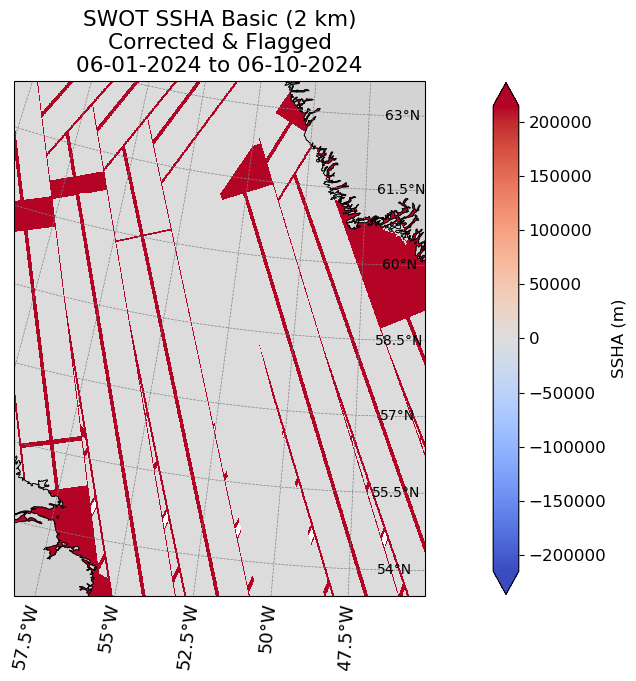

CPU times: user 9.96 s, sys: 1.17 s, total: 11.1 s
Wall time: 1min 3s


In [96]:
%%time
plt.rcParams['font.size'] = 13

fig = plt.figure(figsize=(10, 7))
map_proj = ccrs.NorthPolarStereo(central_longitude=-45)
ax = fig.add_subplot(1, 1, 1, projection=map_proj)

ax.set_extent([-58.5, -45, 53.5, 63], crs=ccrs.PlateCarree())

for feature, kwargs in [
    ('land', dict(facecolor='lightgray', edgecolor='black')),
    ('coastline', dict(facecolor='none', edgecolor='black')),
]:
    ax.add_feature(cfeature.NaturalEarthFeature('physical', feature, '10m', **kwargs), linewidth=0.5)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.left_labels = True
gl.bottom_labels = True
gl.ylabel_style = {'size': 10, 'rotation': 0}

for i in range(len(ssha_corrected.granule)):
    pp = ssha_corrected.isel(granule=i).plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), x="longitude", y="latitude",
        cmap="coolwarm", add_colorbar=False,
    )

cbar = plt.colorbar(pp, ax=ax, orientation="vertical", extend='both', fraction=0.03, pad=0.08)
cbar.set_label("SSHA (m)", fontsize=12)
cbar.ax.tick_params(labelsize=12)

plt.title(f'SWOT SSHA Basic (2 km)\nCorrected & Flagged\n{title_time}')
plt.tight_layout()
plt.show()

## Plot

In [97]:
data_vds_subset['ssha_karin_2_corrected'] = data_vds_subset.ssha_karin_2 + data_vds_subset.height_cor_xover
data_vds_subset.ssha_karin_2_corrected

<xarray.DataArray 'ssha_karin_2_corrected' (granule: 24, num_lines: 9866,
                                            num_pixels: 69)> Size: 131MB
dask.array<add, shape=(24, 9866, 69), dtype=float64, chunksize=(1, 9866, 69), chunktype=numpy.ndarray>
Coordinates:
    cycle      (granule) float64 192B 16.0 16.0 16.0 16.0 ... 16.0 16.0 16.0
    filename   (granule) object 192B 'SWOT_L2_LR_SSH_Basic_016_089_20240601T0...
  * granule    (granule) float64 192B 7.896e+03 7.907e+03 ... 8.159e+03
    latitude   (granule, num_lines, num_pixels) float64 131MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    longitude  (granule, num_lines, num_pixels) float64 131MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    orbit      (granule) datetime64[ms] 192B 2024-06-01T08:17:05.154000 ... 2...
    ppass      (granule) float64 192B 89.0 100.0 102.0 ... 341.0 350.0 352.0
Dimensions without coordinates: num_lines, num_pixels

In [99]:
# without 512
# flag_masks = [1,2,4,8,16,64,128,256,1024,2048,4096,8192,32768,65536,131072,262144,524288,16777216,33554432,67108864,536870912,1073741824,2147483648]

# all flags removed
flag_masks = data_vds_subset.ssha_karin_2_qual.flag_masks

qual = data_vds_subset.ssha_karin_2_qual.astype("uint32")
bad_mask = xr.zeros_like(qual, dtype=bool)
for f in flag_masks:
    bad_mask = bad_mask | ((qual & np.uint32(f)) != 0)

good = (~bad_mask) & (data_vds_subset.rain_flag == 0)
data_vds_subset['ssha_karin_2_corrected'] = data_vds_subset.ssha_karin_2_corrected.where(good)

In [100]:
ssha_corrected = data_vds_subset.ssha_karin_2_corrected

In [101]:
mask = (
    (ssha_corrected.latitude >= 40) & (ssha_corrected.latitude <= 80) &
    (ssha_corrected.longitude >= 300) & (ssha_corrected.longitude <= 320)
).compute()

ssha_greenland = ssha_corrected.where(mask, drop=True).load()

In [102]:
time_vals = pd.to_datetime(data_vds_subset.time.values)
time_vals = time_vals[~pd.isnull(time_vals)]
time_start = time_vals[0]
time_end = time_vals[-1]
title_time = f"{time_start.strftime('%m-%d-%Y')} to {time_end.strftime('%m-%d-%Y')}"

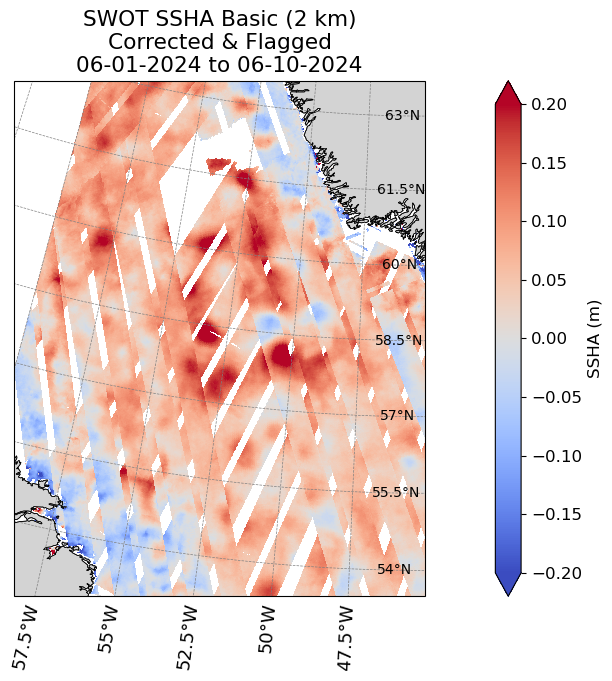

In [105]:
plt.rcParams['font.size'] = 13

fig = plt.figure(figsize=(10, 7))
map_proj = ccrs.NorthPolarStereo(central_longitude=-45)
ax = fig.add_subplot(1, 1, 1, projection=map_proj)

ax.set_extent([-58.5, -45, 53.5, 63], crs=ccrs.PlateCarree())
# ax.set_extent([-60, -40, 52, 65], crs=ccrs.PlateCarree())  # Greenland region

for feature, kwargs in [
    ('land', dict(facecolor='lightgray', edgecolor='black')),
    ('coastline', dict(facecolor='none', edgecolor='black')),
]:
    ax.add_feature(cfeature.NaturalEarthFeature('physical', feature, '10m', **kwargs), linewidth=0.5)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.left_labels = True
gl.bottom_labels = True
gl.ylabel_style = {'size': 10, 'rotation': 0}  # keeps lat labels upright on outside

for i in range(len(ssha_greenland.granule)):
    pp = ssha_greenland.isel(granule=i).plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), x="longitude", y="latitude",vmin=-0.2,vmax=0.2,
        cmap="coolwarm", add_colorbar=False,
    )

cbar = plt.colorbar(pp, ax=ax, orientation="vertical", extend='both', fraction=0.03, pad=0.08)
cbar.set_label("SSHA (m)", fontsize=12)
cbar.ax.tick_params(labelsize=12)

plt.title(f'SWOT SSHA Basic (2 km)\nCorrected & Flagged\n{title_time}')

plt.tight_layout()
plt.show()